# 💻 مشروع تحليل والتنبؤ بدرجات حرارة المعالج (CPU Temperature Prediction)
يقوم هذا الملف بتحليل بيانات مؤشرات الأداء للأجهزة، تنظيفها، ومن ثم بناء وتدريب نموذج ذكاء اصطناعي تفاعلي للتنبؤ بدرجات الحرارة وحفظ النموذج ليتم تشغيله عبر سيرفر Flask.

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

### 1. تحميل واستكشاف البيانات

In [8]:
# تحميل ملف البيانات الأساسي
df = pd.read_csv('Computer_metrics.csv')
print("--- معلومات عامة عن البيانات ---")
print(df.info())
print("\n--- الإحصاءات الوصفية الأولية ---")
print(df.describe())

--- معلومات عامة عن البيانات ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28407 entries, 0 to 28406
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Timestamp        28407 non-null  object 
 1   CPU_Usage        28407 non-null  float64
 2   CPU_Frequency    28407 non-null  float64
 3   Memory_Usage     28407 non-null  float64
 4   Disk_Usage       28407 non-null  float64
 5   Process_Count    28407 non-null  int64  
 6   Thread_Count     28407 non-null  int64  
 7   CPU_Temperature  28080 non-null  float64
 8   GPU_Temperature  28087 non-null  float64
dtypes: float64(6), int64(2), object(1)
memory usage: 2.0+ MB
None

--- الإحصاءات الوصفية الأولية ---
          CPU_Usage  CPU_Frequency  Memory_Usage    Disk_Usage  Process_Count  \
count  28407.000000        28407.0  28407.000000  28407.000000   28407.000000   
mean      16.936167         3793.0     52.150463     76.490217     184.373499   
std     

### 2. تنظيف ومعالجة البيانات (Data Cleaning)

In [9]:
# حذف الصفوف التي تحتوي على قيم مفقودة في الأعمدة الرئيسية
df_clean = df.dropna(subset=['CPU_Usage', 'CPU_Temperature', 'Memory_Usage'], how='any')

# حذف عمود التردد CPU_Frequency إذا كان موجوداً بسبب عدم الحاجة إليه أو كثرة القيم المفقودة
if 'CPU_Frequency' in df_clean.columns:
    df_clean.drop(columns=['CPU_Frequency'], inplace=True, errors='ignore')

print("\n--- عدد القيم المفقودة بعد التنظيف ---")
print(df_clean.isnull().sum())


--- عدد القيم المفقودة بعد التنظيف ---
Timestamp          0
CPU_Usage          0
Memory_Usage       0
Disk_Usage         0
Process_Count      0
Thread_Count       0
CPU_Temperature    0
GPU_Temperature    0
dtype: int64


C:\Users\pc\AppData\Local\Temp\ipykernel_7036\2550538599.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean.drop(columns=['CPU_Frequency'], inplace=True, errors='ignore')


### 3. تحليل العلاقات والرسم البياني (Data Visualization)

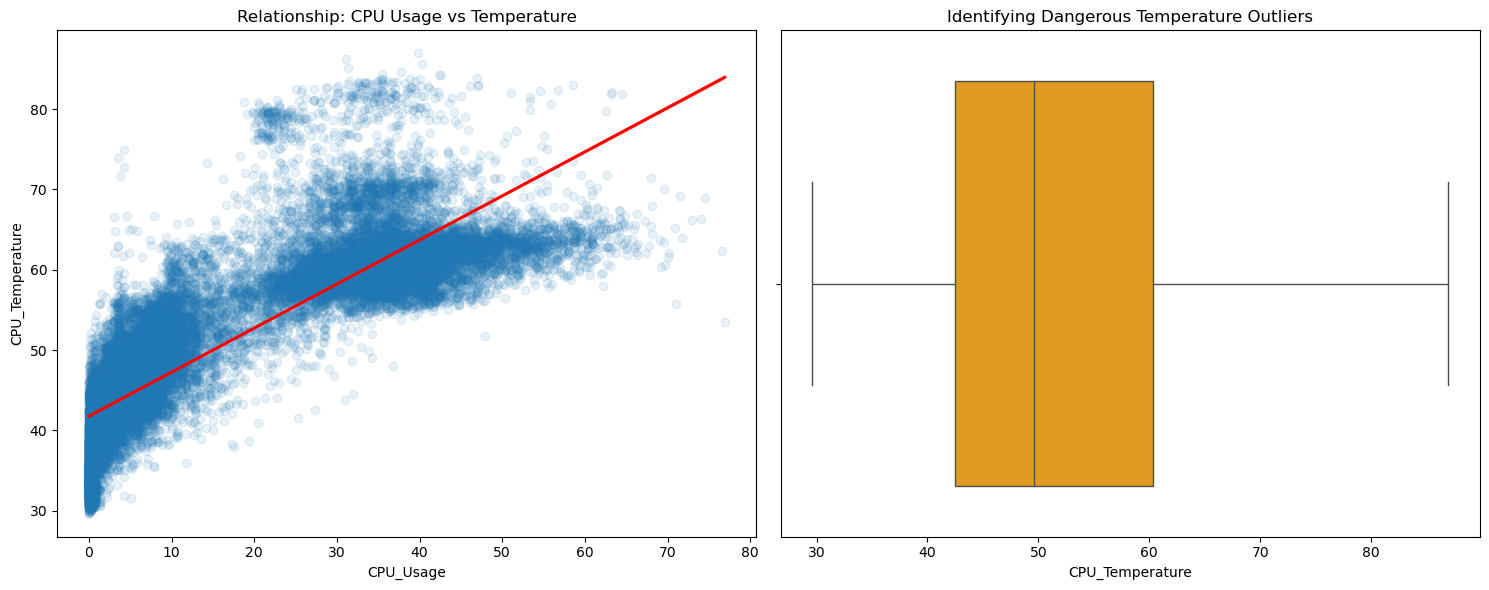


Percentage of devices in Danger Zone (>85°C): 0.01%


In [10]:
plt.figure(figsize=(15, 6))

# المخطط الأول: العلاقة بين الاستخدام والحرارة مع خط الانحدار
plt.subplot(1, 2, 1)
sns.regplot(data=df_clean, x='CPU_Usage', y='CPU_Temperature', 
            scatter_kws={'alpha':0.1}, line_kws={'color':'red'})
plt.title('Relationship: CPU Usage vs Temperature')

# المخطط الثاني: مخطط الصندوق لرصد القيم الخطرة (Outliers)
plt.subplot(1, 2, 2)
sns.boxplot(x=df_clean['CPU_Temperature'], color='orange')
plt.title('Identifying Dangerous Temperature Outliers')

plt.tight_layout()
plt.show()

# حساب نسبة الأجهزة في منطقة الخطر
danger_zone = df_clean[df_clean['CPU_Temperature'] > 85]
percentage = (len(danger_zone) / len(df_clean)) * 100
print(f"\nPercentage of devices in Danger Zone (>85°C): {percentage:.2f}%")

### 4. بناء وتدريب نماذج الذكاء الاصطناعي (Model Training)

In [11]:
# تحديد المتغيرات المستقلة والهدف
features = ['CPU_Usage', 'Memory_Usage', 'Disk_Usage', 'Process_Count', 'Thread_Count', 'GPU_Temperature']
target = 'CPU_Temperature'

X = df_clean[features]
y = df_clean[target]

# تقسيم البيانات إلى تدريب واختبار
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# تدريب نموذج Random Forest
print("جاري تدريب نموذج Random Forest...")
rf = RandomForestRegressor(random_state=42, n_estimators=100)
rf.fit(X_train, y_train)

print("✅ تم التدريب بنجاح!")

جاري تدريب نموذج Random Forest...
✅ تم التدريب بنجاح!


### 5. تقييم النموذج المقارن وحفظه (Evaluation & Export)

In [12]:
# تقييم دقة النموذج
score = rf.score(X_test, y_test)
print(f"Random Forest R^2 Score on Test Set: {score:.2f}")

# حفظ النموذج لاستخدامه في تطبيق الويب الفلاسم
# model_path = 'project_analysis_1.joblib'
# joblib.dump(rf, model_path)
# print(f"\n✅ Model saved successfully as '{model_path}'")
import joblib
import os

# تحديد المسار الحالي بدقة وحفظ النموذج باسم دقيق
model_path = os.path.join(os.getcwd(), 'project_analysis_1.joblib')
joblib.dump(rf, model_path) # تأكد أن اسم متغير النموذج هنا هو model أو استبدله باسم متغيرك

print(f"تم حفظ النموذج بنجاح في المسار التالي:\n{model_path}")

Random Forest R^2 Score on Test Set: 0.95
تم حفظ النموذج بنجاح في المسار التالي:
d:\AI_PATH_PYTHON\project_analysis _1\project_analysis_1.joblib
